# Optimisation du Pipeline ML pour la prédiction du Diabète
Ce notebook approfondit l'entraînement et l'évaluation avec MLflow, SHAP, K-Means et cross-validation.


## BLOC 1 — Recharger et préparer (Préparation propre)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score, roc_auc_score, accuracy_score, roc_curve, confusion_matrix
from imblearn.combine import SMOTEENN
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import shap
import mlflow
import mlflow.sklearn
import pathlib

# Créer le dossier outputs
os.makedirs("outputs", exist_ok=True)

# Charger les données (assumant target = Outcome)
df = pd.read_csv("data/diabetes.csv")

# Remplacer les 0 par NaN sur les colonnes spécifiques
cols_to_nan = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_nan] = df[cols_to_nan].replace(0, np.nan)

# Séparation X et y
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split train/test EN PREMIER
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Imputer avec KNNImputer (fit sur train uniquement)
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_raw), columns=X_test_raw.columns)

# Feature Engineering
def engineer_features(df_to_eng):
    df_new = df_to_eng.copy()
    df_new['glucose_bmi'] = df_new['Glucose'] * df_new['BMI']
    
    def categorize_bmi(bmi):
        if bmi < 25: return 0
        elif bmi < 30: return 1
        else: return 2
        
    def categorize_glucose(glu):
        if glu < 100: return 0
        elif glu < 126: return 1
        else: return 2
        
    df_new['bmi_category'] = df_new['BMI'].apply(categorize_bmi)
    df_new['glucose_category'] = df_new['Glucose'].apply(categorize_glucose)
    return df_new

X_train_eng = engineer_features(X_train_imputed)
X_test_eng = engineer_features(X_test_imputed)

# Scaler (fit sur train uniquement)
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_eng), columns=X_train_eng.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_eng), columns=X_test_eng.columns)

# SMOTEENN pour rééquilibrer (sur train uniquement)
smoteenn = SMOTEENN(random_state=42)
X_res, y_res = smoteenn.fit_resample(X_train_scaled, y_train)

# Assignation finale
X_train = X_res
y_train = y_res
X_test = X_test_scaled    # Requis pour les blocs suivants

print("Dimensions : Entraînement", X_train.shape, "Test", X_test.shape)

Dimensions : Entraînement (501, 11) Test (154, 11)


## BLOC 2 — Entraîner Random Forest optimisé


In [2]:
# Grille de paramètres
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None],
    'max_features': ['sqrt', 'log2']
}

# CV Stratifiée
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Recherche Aléatoire
rf = RandomForestClassifier(random_state=42)
rs = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, 
                        n_iter=50, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)

best_model = rs.best_estimator_
print("Meilleurs paramètres :", rs.best_params_)

Meilleurs paramètres : {'n_estimators': 500, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}


## BLOC 3 — Optimisation du seuil de décision


Seuil optimal : 0.61 (F1: 0.699, Recall: 0.796, Precision: 0.623)


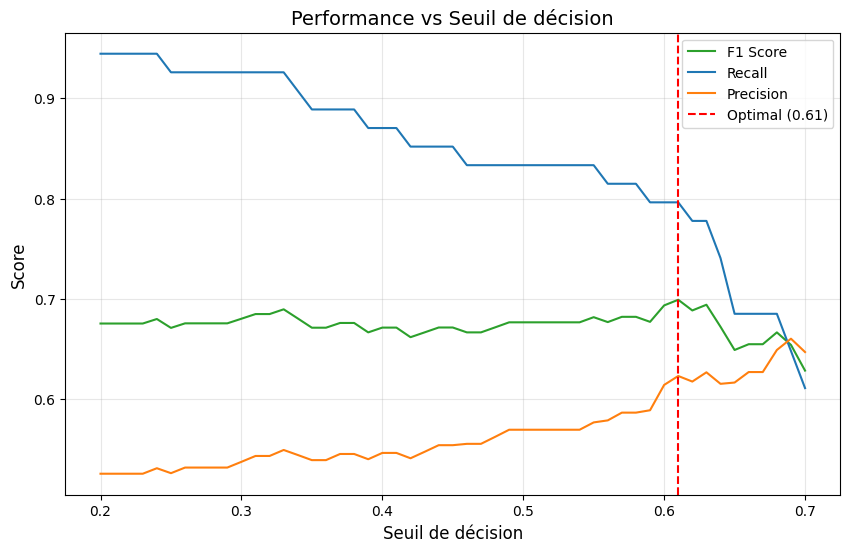

In [3]:
y_probs = best_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.20, 0.71, 0.01)

f1_scores, recalls, precisions = [], [], []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))
    recalls.append(recall_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t))

# Trouver le seuil optimal pour F1
opt_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[opt_idx]
optimal_f1 = f1_scores[opt_idx]
optimal_recall = recalls[opt_idx]
optimal_precision = precisions[opt_idx]

print(f"Seuil optimal : {optimal_threshold:.2f} (F1: {optimal_f1:.3f}, Recall: {optimal_recall:.3f}, Precision: {optimal_precision:.3f})")

# Préparation Fig 3
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1 Score', color='#2ca02c')
plt.plot(thresholds, recalls, label='Recall', color='#1f77b4')
plt.plot(thresholds, precisions, label='Precision', color='#ff7f0e')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal ({optimal_threshold:.2f})')
plt.title('Performance vs Seuil de décision', fontsize=14)
plt.xlabel('Seuil de décision', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('outputs/fig3_threshold_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## BLOC 4 — Cross-validation finale (obligatoire pour l'article)


In [4]:
cv_acc, cv_prec, cv_rec, cv_f1, cv_auc = [], [], [], [], []

# Evaluation sur l'ensemble entier (X, y) pour éviter tout data leakage
cv_eval = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for train_idx, val_idx in cv_eval.split(X, y):
    X_f_train_raw, X_f_val_raw = X.iloc[train_idx], X.iloc[val_idx]
    y_f_train, y_f_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # KNNImputer
    imputer_fold = KNNImputer(n_neighbors=5)
    X_f_train_imp = pd.DataFrame(imputer_fold.fit_transform(X_f_train_raw), columns=X_f_train_raw.columns)
    X_f_val_imp = pd.DataFrame(imputer_fold.transform(X_f_val_raw), columns=X_f_val_raw.columns)
    
    # Feature Engineering
    X_f_train_eng = engineer_features(X_f_train_imp)
    X_f_val_eng = engineer_features(X_f_val_imp)
    
    # RobustScaler
    scaler_fold = RobustScaler()
    X_f_train_sca = pd.DataFrame(scaler_fold.fit_transform(X_f_train_eng), columns=X_f_train_eng.columns)
    X_f_val_sca = pd.DataFrame(scaler_fold.transform(X_f_val_eng), columns=X_f_val_eng.columns)
    
    # SMOTEENN
    smoteenn_fold = SMOTEENN(random_state=42)
    X_f_res, y_f_res = smoteenn_fold.fit_resample(X_f_train_sca, y_f_train)
    
    # Entraînement avec les meilleurs paramètres
    model_cv = RandomForestClassifier(**rs.best_params_, random_state=42)
    model_cv.fit(X_f_res, y_f_res)
    
    # Prédictions sur le test fold
    probs = model_cv.predict_proba(X_f_val_sca)[:, 1]
    preds = (probs >= optimal_threshold).astype(int)
    
    cv_acc.append(accuracy_score(y_f_val, preds))
    cv_prec.append(precision_score(y_f_val, preds))
    cv_rec.append(recall_score(y_f_val, preds))
    cv_f1.append(f1_score(y_f_val, preds))
    cv_auc.append(roc_auc_score(y_f_val, probs))

cv_metrics = pd.DataFrame({
    'Accuracy': cv_acc, 'Precision': cv_prec, 'Recall': cv_rec, 'F1': cv_f1, 'AUC': cv_auc
})

print("Résultats Cross-Validation (10-fold) complète sans leakage avec seuil optimal :")
for col in cv_metrics.columns:
    print(f"{col}: {cv_metrics[col].mean():.3f} ± {cv_metrics[col].std():.3f}")

Résultats Cross-Validation (10-fold) complète sans leakage avec seuil optimal :
Accuracy: 0.765 ± 0.064
Precision: 0.644 ± 0.093
Recall: 0.757 ± 0.114
F1: 0.692 ± 0.086
AUC: 0.835 ± 0.045


## BLOC 5 — SHAP (contribution principale)


In [5]:
# Interprétabilité avec SHAP
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
# Sélection des valeurs pour la classe positive (1)
shap_pos = shap_values[:, :, 1] if len(np.shape(shap_values)) == 3 else shap_values

# 1. Beeswarm
plt.figure()
shap.summary_plot(shap_pos, X_test, show=False)
plt.savefig('outputs/shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
plt.clf()

# 2. Bar plot (Global) - top 8
plt.figure()
shap.summary_plot(shap_pos, X_test, plot_type="bar", max_display=8, show=False)
plt.savefig('outputs/shap_bar_global.png', dpi=300, bbox_inches='tight')
plt.savefig('outputs/fig5_shap_importance.png', dpi=300, bbox_inches='tight')  # Same as fig5
plt.clf()

# 3. Waterfall plot (Patient 0)
shap_exp = explainer(X_test)
if len(shap_exp.shape) == 3:
    shap_exp = shap_exp[:, :, 1]
plt.figure()
shap.waterfall_plot(shap_exp[0], show=False)
plt.savefig('outputs/shap_waterfall_patient0.png', dpi=300, bbox_inches='tight')
plt.clf()

# Top 3 features influentes
mean_shap = np.abs(shap_pos).mean(axis=0)
top_idx = np.argsort(mean_shap)[::-1][:3]
print("Top 3 features les plus influentes :")
for idx in top_idx:
    print(f"{X_test.columns[idx]}: {mean_shap[idx]:.4f}")


Top 3 features les plus influentes :
glucose_bmi: 0.1375
Glucose: 0.0632
SkinThickness: 0.0512


<Figure size 800x590 with 0 Axes>

<Figure size 800x470 with 0 Axes>

<Figure size 800x650 with 0 Axes>

## BLOC 6 — Clustering K-Means


Silhouette Score : 0.165


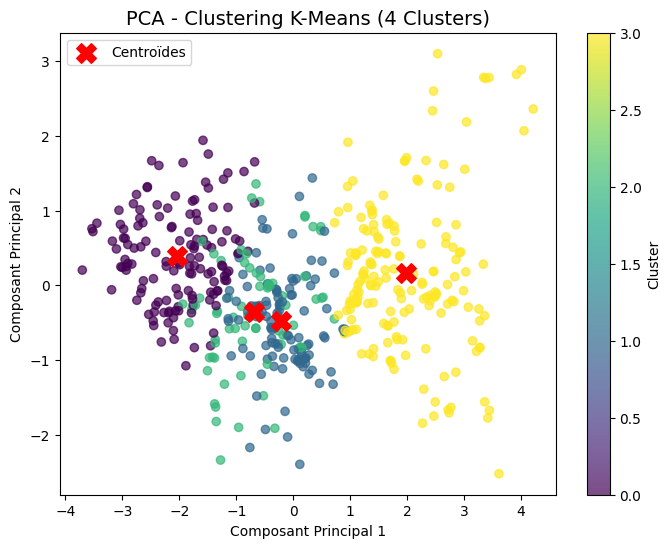

Moyennes des features par cluster :
          Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
Cluster                                                                       
0               2.56   101.50          66.90          20.00    88.37  24.87   
1               2.48   113.49          72.85          31.15   128.33  34.13   
2               5.06    98.77          69.15          27.83    97.09  32.59   
3               5.28   159.84          78.72          35.17   221.46  38.85   

         DiabetesPedigreeFunction    Age  glucose_bmi  bmi_category  \
Cluster                                                               
0                            0.39  27.18      2523.80          0.50   
1                            0.31  31.33      3837.64          1.82   
2                            0.63  34.02      3199.71          1.83   
3                            0.59  37.70      6150.68          2.00   

         glucose_category  
Cluster                    
0    

In [6]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_res)

sil_score = silhouette_score(X_res, clusters)
print(f"Silhouette Score : {sil_score:.3f}")

# PCA pour visualisation
pca = PCA(n_components=2)
components = pca.fit_transform(X_res)

plt.figure(figsize=(8,6))
scatter = plt.scatter(components[:, 0], components[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.title('PCA - Clustering K-Means (4 Clusters)', fontsize=14)
plt.xlabel('Composant Principal 1')
plt.ylabel('Composant Principal 2')
plt.colorbar(scatter, label='Cluster')

# Marquer les centroïdes estimatifs
centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroïdes')
plt.legend()
plt.savefig('outputs/clustering_kmeans.png', dpi=300, bbox_inches='tight')
plt.savefig('outputs/fig6_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Profils par cluster
X_orig = pd.DataFrame(scaler.inverse_transform(X_res.copy()), columns=X_res.columns)
X_orig['Cluster'] = clusters
profils = X_orig.groupby('Cluster').mean()
print("Moyennes des features par cluster :\n", profils.round(2))


## BLOC 7 — Figures publication-ready (complément)


In [7]:
sns.set_theme(style="whitegrid")

# Fig 1 : ROC Comparaison
plt.figure(figsize=(8,6))
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_val = roc_auc_score(y_test, y_probs)
plt.plot(fpr, tpr, color='#d62728', lw=2, label=f'Random Forest Opt. (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Diagonale')
plt.xlabel('Taux Faux Positifs', fontsize=12)
plt.ylabel('Taux Vrais Positifs', fontsize=12)
plt.title('Courbe ROC', fontsize=14)
plt.legend(loc="lower right")
plt.savefig('outputs/fig1_roc_comparaison.png', dpi=300, bbox_inches='tight')
plt.close()

# Fig 2 : Confusion Matrix heatmap (valeurs + % )
plt.figure(figsize=(6,5))
y_pred_opt = (y_probs >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
cat_labels = ['Vrai Neg', 'Faux Pos', 'Faux Neg', 'Vrai Pos']
counts = [f"{value}" for value in cm.flatten()]
percentages = [f"{value:.1%}" for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(cat_labels, counts, percentages)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', annot_kws={"size": 12})
plt.title(f'Matrice de Confusion', fontsize=14)
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.savefig('outputs/fig2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.close()

# Fig 4 : CV Boxplots
plt.figure(figsize=(10,6))
cv_melt = cv_metrics.melt(var_name='Métrique', value_name='Score')
sns.boxplot(x='Métrique', y='Score', data=cv_melt, palette="coolwarm")
plt.axhline(y=0.80, color='black', linestyle='--', alpha=0.7, label='Objectif 0.80')
plt.title('Distribution des performances sur 10 folds', fontsize=14)
plt.legend()
plt.savefig('outputs/fig4_cv_boxplots.png', dpi=300, bbox_inches='tight')
plt.close()


## BLOC 8 — MLflow logging complet


In [8]:
import os
import mlflow
import pathlib

# Résolution des erreurs d'artefacts avec la base SQLite sous Windows
tracking_uri = "sqlite:///mlflow.db"
mlflow.set_tracking_uri(tracking_uri)

# Créer une expérience dédiée avec un chemin explicite et local vers les artefacts via pathlib (file:///)
exp_name = "Diabetes_Optimization"
artifact_path = pathlib.Path(os.path.abspath("mlruns")).as_uri()

exp = mlflow.get_experiment_by_name(exp_name)
if exp is None:
    mlflow.create_experiment(exp_name, artifact_location=artifact_path)
mlflow.set_experiment(exp_name)

# Terminer tout run existant pour le relancer proprement
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="OptimizedPipeline_Corrected"):
    # Paramètres
    mlflow.log_params(rs.best_params_)
    mlflow.log_param("knn_neighbors", 5)
    mlflow.log_param("smoteenn_random_state", 42)
    
    # Métriques
    mlflow.log_metric("threshold_optimal", optimal_threshold)
    mlflow.log_metric("f1_optimized", optimal_f1)
    mlflow.log_metric("recall_optimized", optimal_recall)
    mlflow.log_metric("precision_optimized", optimal_precision)
    mlflow.log_metric("auc_test", auc_val)
    mlflow.log_metric("silhouette_score_k4", sil_score)
    
    # Métriques issues de la cross-validation
    for col in cv_metrics.columns:
        mlflow.log_metric(f"CV_mean_{col}", cv_metrics[col].mean())
        mlflow.log_metric(f"CV_std_{col}", cv_metrics[col].std())
        
    # Modèle complet
    mlflow.sklearn.log_model(best_model, "RandomForest_Optimized")
    
    # Artefacts (Figures issues du dossier outputs)
    figs_to_log = [
        "shap_summary_beeswarm.png", "shap_bar_global.png", "shap_waterfall_patient0.png",
        "clustering_kmeans.png", "fig1_roc_comparaison.png", "fig2_confusion_matrix.png",
        "fig3_threshold_curve.png", "fig4_cv_boxplots.png", "fig5_shap_importance.png",
        "fig6_clusters.png"
    ]
    for fig in figs_to_log:
        f_path = os.path.join("outputs", fig)
        if os.path.exists(f_path):
            mlflow.log_artifact(f_path, artifact_path="figures")

print("Pipeline optimisé finalisé. MLflow log effectué avec succès !")

2026/04/12 20:46:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 20:46:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Pipeline optimisé finalisé. MLflow log effectué avec succès !
